# Semana 6 - Modelo supervisionado MLP com scikit-learn

**Inteligencia Computacional I - Deteccao de fraude em cartao de credito**

## Objetivo

Testar uma rede neural MLP supervisionada (`sklearn.neural_network.MLPClassifier`)
na populacao completa de `dados/creditcard.csv`, comparando-a com os Random Forests
da Semana 5 e verificando se os clusters K-Means/DBSCAN agregam mais valor para uma
rede neural do que agregaram para arvores.

O protocolo permanece igual ao da Semana 5:

- base completa deduplicada: 283.726 transacoes, 473 fraudes;
- split estratificado 80/20 com `random_state=42`;
- validacao cruzada estratificada com 5 folds;
- metricas principais: AUC-ROC, Average Precision, Recall, Precision e F1;
- acuracia nao e usada como criterio por causa do forte desbalanceamento.

## 0. Setup

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT_DIR = ROOT / "resultados"
FIG_DIR = OUT_DIR / "figuras"
PRED_DIR = OUT_DIR / "preds"

sys.path.insert(0, str(ROOT))
from scripts.semana_6_modelo_mlp import (  # noqa: E402
    RANDOM_STATE,
    TEST_SIZE,
    build_feature_matrices,
    fit_mlp,
    load_dataset,
    make_mlp_pipeline,
)

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print("ROOT:", ROOT)
print("TEST_SIZE:", TEST_SIZE, "| RANDOM_STATE:", RANDOM_STATE)

ROOT: /Users/ruanneres/www/person/project/fraud-detection
TEST_SIZE: 0.2 | RANDOM_STATE: 42


## 1. Carregamento da base completa e dos clusters

O notebook reutiliza `resultados/semana_5_clusters_base_completa.csv`, sem recalcular
K-Means ou DBSCAN. A funcao `load_dataset()` valida se a coluna `Class` do arquivo de
clusters ainda corresponde a base deduplicada.

In [2]:
dataset = load_dataset()
y = dataset["Class"].astype(int)
matrices = build_feature_matrices(dataset)

print(f"Registros: {len(dataset):,}")
print(f"Fraudes: {int(y.sum()):,}")
print(f"Taxa de fraude: {y.mean():.4%}")
print("Matrizes:")
for nome, X in matrices.items():
    print(f"- {nome}: {X.shape}")

Registros: 283,726
Fraudes: 473
Taxa de fraude: 0.1667%
Matrizes:
- baseline: (283726, 30)
- clusters: (283726, 38)
- dbscan: (283726, 32)


## 2. Por que `StandardScaler` e obrigatorio no MLP

O Random Forest das Semanas 4 e 5 usa arvores, portanto nao depende da escala absoluta
das variaveis. O MLP usa otimizacao por gradiente (`adam`) e funcoes de ativacao; sem
padronizacao, variaveis como `Amount` e `Time` podem dominar o treinamento.

Por isso o classificador e encapsulado em:

```python
Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(...))
])
```

Observacao de compatibilidade: a versao local do scikit-learn nao tem parametro
`class_weight` em `MLPClassifier`. O script aplica a mesma ideia com
`sample_weight="balanced"` no `fit`, que e a API suportada pelo ambiente.

## 3. Exemplo minimo didatico: `fit` -> `predict_proba`

In [3]:
# Subset pequeno e estratificado manualmente para demonstracao rapida.
fraudes = dataset[dataset["Class"] == 1].sample(n=100, random_state=RANDOM_STATE)
legitimas = dataset[dataset["Class"] == 0].sample(n=5000, random_state=RANDOM_STATE)
mini = pd.concat([legitimas, fraudes]).sample(frac=1, random_state=RANDOM_STATE)

X_mini = mini[["Time", "Amount"] + [f"V{i}" for i in range(1, 29)]]
y_mini = mini["Class"].astype(int)

x_train, x_test, y_train, y_test = train_test_split(
    X_mini,
    y_mini,
    test_size=0.2,
    stratify=y_mini,
    random_state=RANDOM_STATE,
)

mini_model = fit_mlp(make_mlp_pipeline(), x_train, y_train)
probas = mini_model.predict_proba(x_test)[:, 1]
preds = mini_model.predict(x_test)

print("Exemplo minimo")
print("- treino:", x_train.shape, "| teste:", x_test.shape)
print("- iteracoes ate parada:", mini_model.named_steps["mlp"].n_iter_)
print("- Average Precision:", f"{average_precision_score(y_test, probas):.4f}")
pd.DataFrame({"y_real": y_test.to_numpy()[:10], "prob_fraude": probas[:10], "pred": preds[:10]})

Exemplo minimo
- treino: (4080, 30) | teste: (1020, 30)
- iteracoes ate parada: 23
- Average Precision: 0.9444


,y_real,prob_fraude,pred
0,0,0.0005,0
1,0,0.2633,0
2,0,0.0384,0
3,0,0.3276,0
4,0,0.0390,0
5,0,0.0033,0
6,0,0.0528,0
7,0,0.0232,0
8,0,0.0163,0
9,1,0.4692,0


## 4. Pipeline completo e ajustes

O pipeline reprodutivel esta em `scripts/semana_6_modelo_mlp.py`. Alem dos tres MLPs
iniciais, o script executa:

- **Regressao Logistica balanceada** como baseline linear escalonado;
- **variantes de MLP** com arquiteturas menores e maior regularizacao (`alpha`);
- **calibracao de probabilidades** (`CalibratedClassifierCV`, metodo sigmoid);
- **ajuste de limiar** na validacao interna, buscando aumentar Precision sem perder
  Recall abaixo de 72% (referencia do RF baseline).

O Random Forest da Semana 5 permanece como **referencia principal** ate que outro
modelo supere AP e F1 de forma consistente.

In [4]:
required_outputs = [
    OUT_DIR / "semana_6_metricas_mlp.csv",
    OUT_DIR / "semana_6_metricas_ajustadas.csv",
    OUT_DIR / "semana_6_comparacao_modelos_ajustada.csv",
    OUT_DIR / "semana_6_resumo_referencia_rf.csv",
]

if not all(path.exists() for path in required_outputs):
    print("Saidas da Semana 6 nao encontradas. Executando script completo...")
    subprocess.run([sys.executable, str(ROOT / "scripts" / "semana_6_modelo_mlp.py")], check=True)
else:
    print("Saidas da Semana 6 encontradas. Carregando CSVs existentes.")

metricas_mlp = pd.read_csv(OUT_DIR / "semana_6_metricas_mlp.csv")
metricas_ajustadas = pd.read_csv(OUT_DIR / "semana_6_metricas_ajustadas.csv")
comparacao = pd.read_csv(OUT_DIR / "semana_6_comparacao_rf_vs_mlp.csv")
comparacao_ajustada = pd.read_csv(OUT_DIR / "semana_6_comparacao_modelos_ajustada.csv")
resumo_rf = pd.read_csv(OUT_DIR / "semana_6_resumo_referencia_rf.csv")
metricas_mlp

Saidas da Semana 6 encontradas. Carregando CSVs existentes.


,familia,modelo,n_features,n_registros,fraudes,threshold,calibrado,auc_roc_teste,average_precision_teste,recall_teste,...,tp,auc_roc_cv_media,auc_roc_cv_desvio,avg_precision_cv_media,avg_precision_cv_desvio,recall_cv_media,precision_cv_media,f1_cv_media,pred_key,observacao
0,MLP,MLP baseline (sem clusters) - base completa,30,283726,473,0.5000,False,0.9549,0.7325,0.8421,...,80,0.9669,0.0176,0.7665,0.0405,0.8774,0.1816,0.2869,mlp_baseline,Baseline neural com 30 features originais.
1,MLP,MLP K-Means + DBSCAN - base completa,38,283726,473,0.5000,False,0.9697,0.7130,0.8737,...,83,0.9709,0.0145,0.7678,0.0265,0.8668,0.2209,0.3463,mlp_clusters,Features originais + K-Means one-hot + ruido D...
2,MLP,MLP apenas DBSCAN - base completa,32,283726,473,0.5000,False,0.9639,0.7475,0.8632,...,82,0.9654,0.0115,0.7703,0.0415,0.8646,0.2458,0.3542,mlp_dbscan,Features originais + sinal binario de ruido DB...
3,Regressao Logistica,Regressao Logistica balanceada - base completa,30,283726,473,0.5000,False,0.9657,0.6719,0.8737,...,83,0.9784,0.0053,0.7125,0.0200,0.9133,0.0609,0.1142,lr_baseline,Baseline linear escalonado com class_weight='b...


## 5. Comparacao inicial (limiar 0.5)

In [5]:
cols = [
    "familia",
    "modelo",
    "n_features",
    "auc_roc_teste",
    "average_precision_teste",
    "recall_teste",
    "precision_teste",
    "f1_teste",
    "auc_roc_cv_media",
    "avg_precision_cv_media",
    "f1_cv_media",
]
comparacao[cols]

,familia,modelo,n_features,auc_roc_teste,average_precision_teste,recall_teste,precision_teste,f1_teste,auc_roc_cv_media,avg_precision_cv_media,f1_cv_media
0,Random Forest,RF baseline (sem clusters) - base completa,30,0.9491,0.8241,0.7263,0.9583,0.8263,0.9587,0.8371,0.8407
1,Random Forest,RF K-Means + DBSCAN - base completa,38,0.9490,0.8122,0.7263,0.9583,0.8263,0.9611,0.8366,0.8470
2,Random Forest,RF apenas DBSCAN - base completa,32,0.9329,0.8083,0.7263,0.9718,0.8313,0.9587,0.8386,0.8423
3,MLP,MLP baseline (sem clusters) - base completa,30,0.9549,0.7325,0.8421,0.1770,0.2925,0.9669,0.7665,0.2869
4,MLP,MLP K-Means + DBSCAN - base completa,38,0.9697,0.7130,0.8737,0.0967,0.1742,0.9709,0.7678,0.3463
5,MLP,MLP apenas DBSCAN - base completa,32,0.9639,0.7475,0.8632,0.0994,0.1783,0.9654,0.7703,0.3542
6,Regressao Logistica,Regressao Logistica balanceada - base completa,30,0.9657,0.6719,0.8737,0.0564,0.1059,0.9784,0.7125,0.1142


## 6. Ajustes: calibracao + limiar + regularizacao

In [6]:
metricas_ajustadas[
    [
        "familia",
        "modelo",
        "threshold",
        "calibrado",
        "average_precision_teste",
        "recall_teste",
        "precision_teste",
        "f1_teste",
        "observacao",
    ]
]

,familia,modelo,threshold,calibrado,average_precision_teste,recall_teste,precision_teste,f1_teste,observacao
0,Regressao Logistica,Regressao Logistica balanceada [limiar 0.529],0.5288,True,0.6988,0.6526,0.8732,0.7470,Baseline linear escalonado. Calibrado + limiar...
1,MLP ajustado,"MLP (64,32) alpha=1e-4 [limiar 0.416]",0.4158,True,0.7558,0.6842,0.8228,0.7471,"Arquitetura (64, 32), alpha=0.0001. Calibrado ..."
2,MLP ajustado,"MLP (32,16) alpha=1e-3 [limiar 0.575]",0.5753,True,0.7185,0.6000,0.8769,0.7125,"Arquitetura (32, 16), alpha=0.001. Calibrado +..."
3,MLP ajustado,"MLP (32,) alpha=1e-3 [limiar 0.657]",0.6568,True,0.7308,0.7158,0.8947,0.7953,"Arquitetura (32,), alpha=0.001. Calibrado + li..."
4,MLP ajustado,"MLP (16,) alpha=1e-2 [limiar 0.595]",0.5948,True,0.7200,0.7368,0.8750,0.8000,"Arquitetura (16,), alpha=0.01. Calibrado + lim..."


## 7. Referencia Random Forest vs desafiantes

In [7]:
resumo_rf

,referencia_rf,rf_ap_cv,rf_f1_cv,rf_ap_teste,rf_f1_teste,melhor_desafiante_ap_teste,melhor_desafiante_f1_teste,algum_supera_rf_consistente
0,RF apenas DBSCAN - base completa,0.8386,0.8423,0.8083,0.8313,"MLP (64,32) alpha=1e-4 [limiar 0.416]","MLP (16,) alpha=1e-2 [limiar 0.595]",False


## 8. Visualizacoes geradas

### `semana_6_matriz_confusao.png`

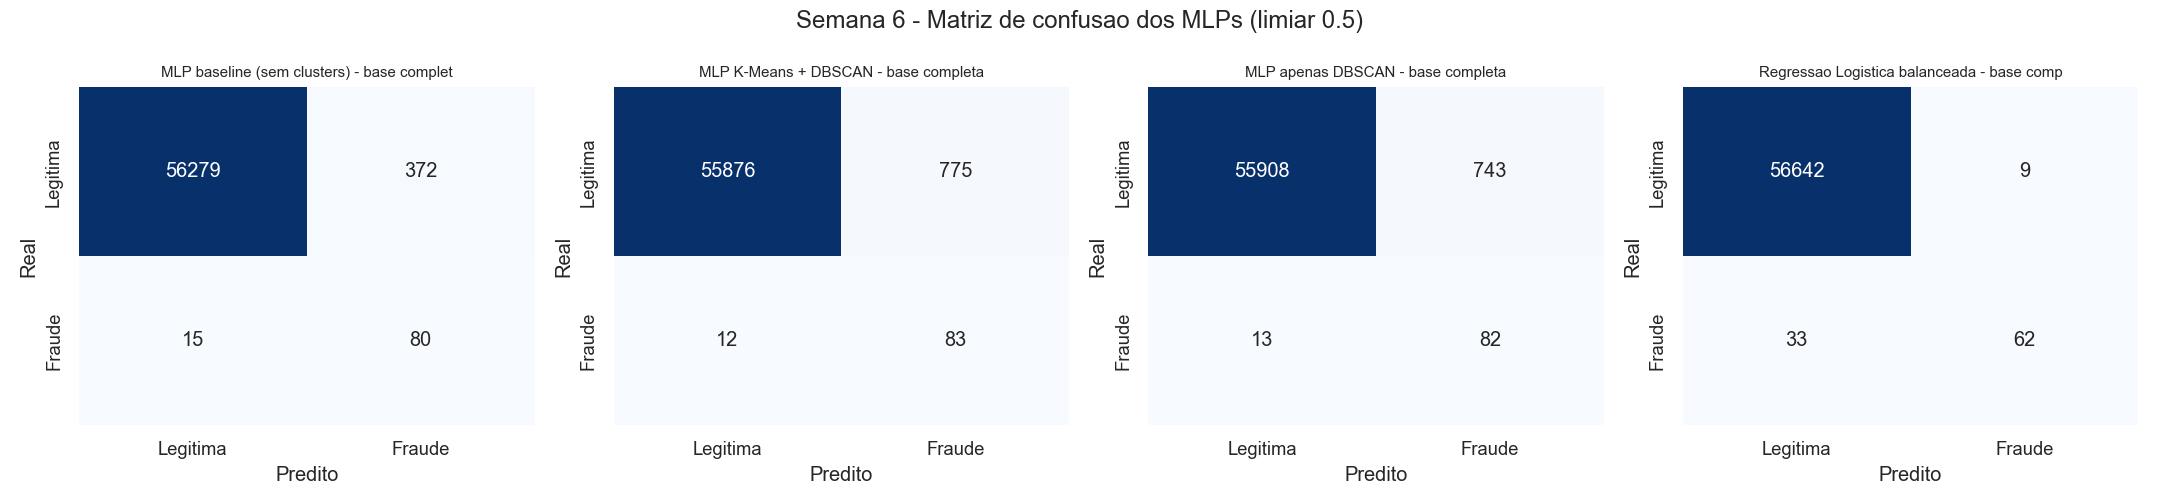

### `semana_6_pr_curve.png`

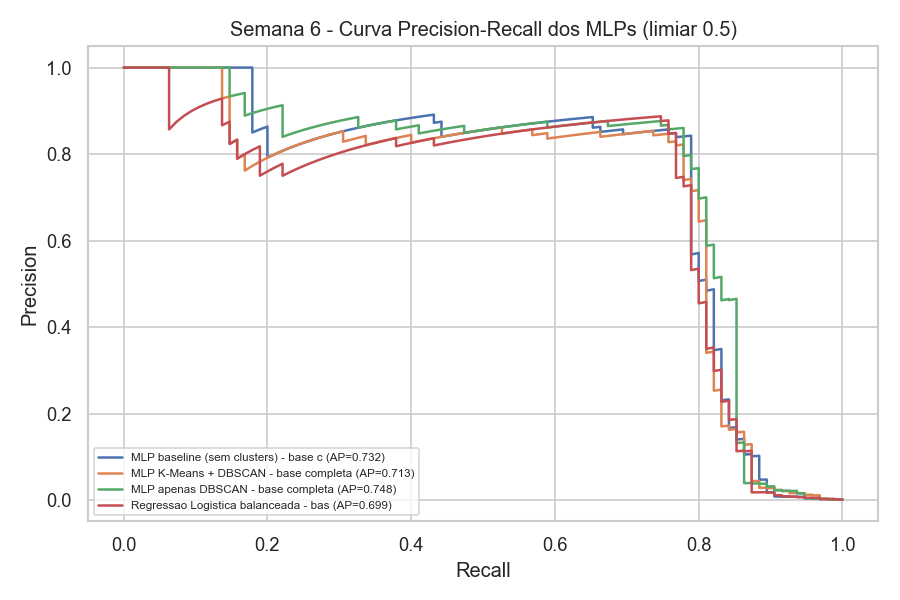

### `semana_6_comparacao_rf_vs_mlp.png`

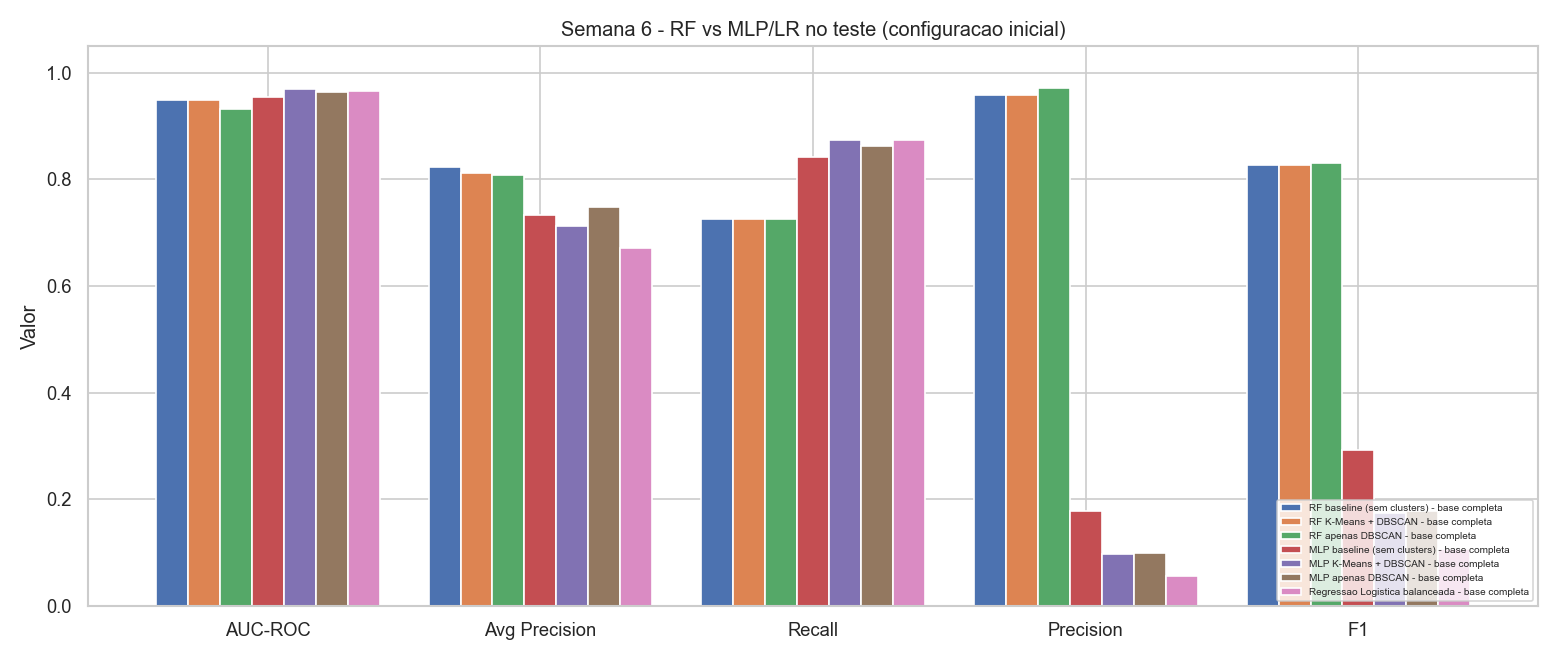

### `semana_6_matriz_confusao_ajustada.png`

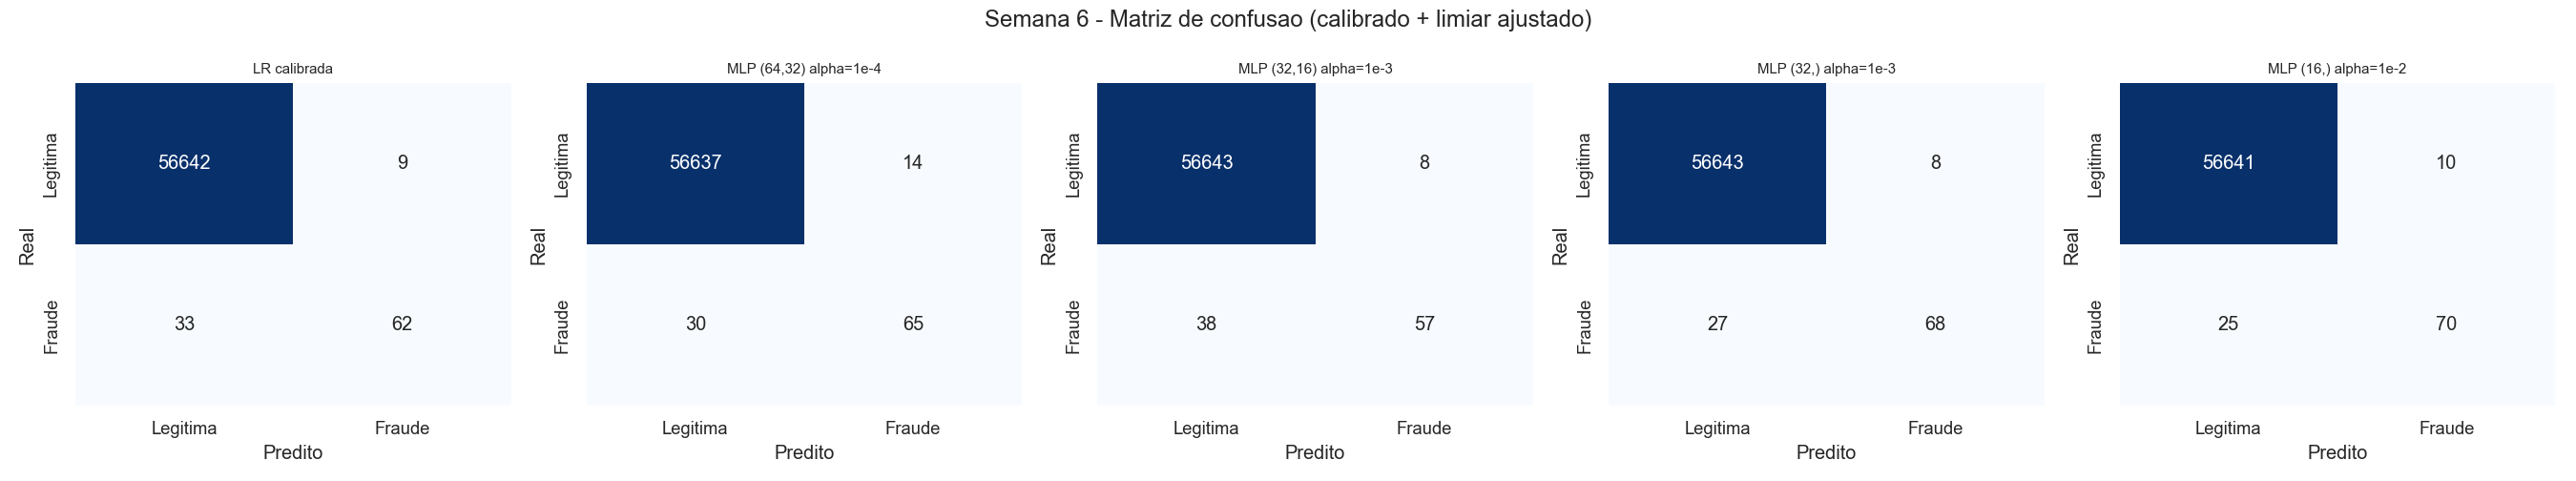

### `semana_6_pr_curve_ajustada.png`

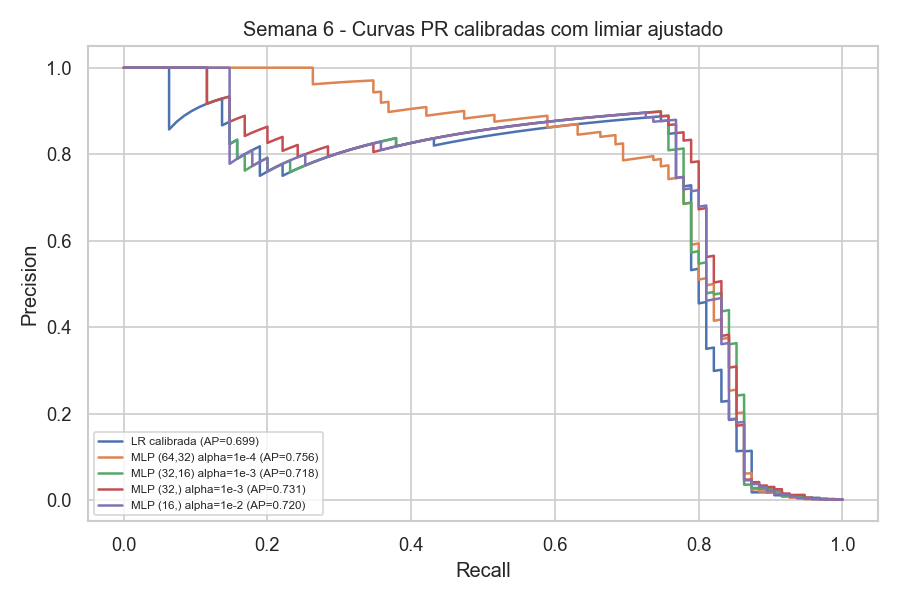

### `semana_6_comparacao_modelos_ajustada.png`

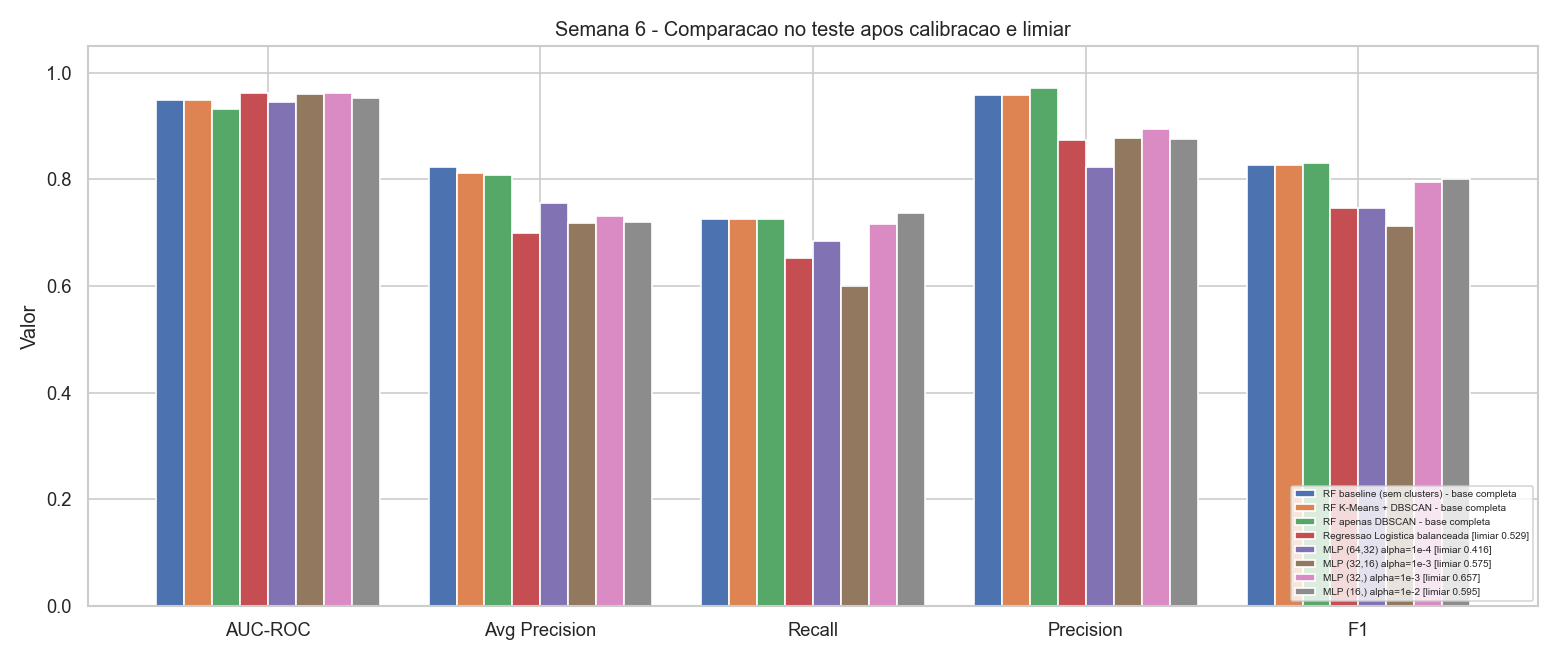

In [8]:
figuras = [
    "semana_6_matriz_confusao.png",
    "semana_6_pr_curve.png",
    "semana_6_comparacao_rf_vs_mlp.png",
    "semana_6_matriz_confusao_ajustada.png",
    "semana_6_pr_curve_ajustada.png",
    "semana_6_comparacao_modelos_ajustada.png",
]

for figura in figuras:
    path = FIG_DIR / figura
    if path.exists():
        display(Markdown(f"### `{figura}`"))
        display(Image(filename=str(path)))

## 9. Conclusao quantitativa

In [9]:
rf = comparacao_ajustada[comparacao_ajustada["familia"] == "Random Forest"].copy()
best_rf = rf.sort_values(["avg_precision_cv_media", "f1_cv_media"], ascending=False).iloc[0]
best_tuned = metricas_ajustadas.sort_values(["f1_teste", "average_precision_teste"], ascending=False).iloc[0]
best_lr = metricas_ajustadas[metricas_ajustadas["familia"] == "Regressao Logistica"].sort_values("f1_teste", ascending=False).iloc[0]
supera_rf = bool(resumo_rf.iloc[0]["algum_supera_rf_consistente"])

texto = (
    f"**Referencia principal:** `{best_rf['modelo']}` com AP(CV)={best_rf['avg_precision_cv_media']:.4f} "
    f"e F1(CV)={best_rf['f1_cv_media']:.4f}.\n\n"
    f"**Melhor modelo ajustado:** `{best_tuned['modelo']}` com AP(teste)={best_tuned['average_precision_teste']:.4f}, "
    f"Recall={best_tuned['recall_teste']:.4f}, Precision={best_tuned['precision_teste']:.4f}, "
    f"F1={best_tuned['f1_teste']:.4f}, limiar={best_tuned['threshold']:.4f}.\n\n"
    f"**Regressao Logistica calibrada:** AP(teste)={best_lr['average_precision_teste']:.4f}, "
    f"F1(teste)={best_lr['f1_teste']:.4f}.\n\n"
    f"**Algum modelo supera o RF de forma consistente (AP e F1)?** "
    f"{'Sim' if supera_rf else 'Nao'} — o Random Forest permanece referencia principal."
)
display(Markdown(texto))

**Referencia principal:** `RF apenas DBSCAN - base completa` com AP(CV)=0.8386 e F1(CV)=0.8423.

**Melhor modelo ajustado:** `MLP (16,) alpha=1e-2 [limiar 0.595]` com AP(teste)=0.7200, Recall=0.7368, Precision=0.8750, F1=0.8000, limiar=0.5948.

**Regressao Logistica calibrada:** AP(teste)=0.6988, F1(teste)=0.7470.

**Algum modelo supera o RF de forma consistente (AP e F1)?** Nao — o Random Forest permanece referencia principal.

## 10. Limitacoes

- Calibracao e limiar foram ajustados em subconjunto de validacao interna; ainda ha risco
  de variacao entre folds.
- O MLP continua menos explicavel que o Random Forest.
- Mesmo com calibracao e limiar, nenhum modelo alternativo superou o RF de forma
  consistente em AP e F1 na validacao cruzada.
- Os clusters permanecem com ganho marginal; o foco desta etapa foi melhorar o
  classificador neural/linear, nao redefinir o clustering.